# 🔮 โหงวเฮ้ง (Ngow Heng) — Face Physiognomy Analyzer
**Fixed version**: Thai text rendered via PIL (Pillow) — no more `?????`  
**Fixed zones**: polygons now hug the actual face features correctly

> Run every cell top-to-bottom. Change `IMAGE_FILE` in Step 7 to use your own photo.

## Step 1 — Install dependencies

In [ ]:
%pip install -q mediapipe opencv-python matplotlib requests pillow numpy

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'b:\\Anaconda\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



## Step 2 — Download model

In [3]:
import requests, os

MODEL_PATH = "face_landmarker_v2_with_blendshapes.task"
MODEL_URL  = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"

if not os.path.exists(MODEL_PATH):
    print("Downloading model...")
    r = requests.get(MODEL_URL)
    with open(MODEL_PATH, "wb") as f:
        f.write(r.content)
    print("✅ Model saved.")
else:
    print(f"✅ Model ready: {MODEL_PATH}")

✅ Model ready: face_landmarker_v2_with_blendshapes.task


## Step 3 — Landmark index map

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ── Eyes ──────────────────────────────────────────────────────────
# Full eye outline (outer contour only — tighter polygon)
LEFT_EYE_CONTOUR  = [33, 246, 161, 160, 159, 158, 157, 173, 133,
                     155, 154, 153, 145, 144, 163, 7]
RIGHT_EYE_CONTOUR = [362, 398, 384, 385, 386, 387, 388, 466, 263,
                     249, 390, 373, 374, 380, 381, 382]
L_EYE_OUTER = 33;   R_EYE_OUTER = 263
L_EYE_INNER = 133;  R_EYE_INNER = 362
L_EYE_TOP   = 159;  L_EYE_BOTTOM = 145
R_EYE_TOP   = 386;  R_EYE_BOTTOM = 374

# ── Eyebrows ──────────────────────────────────────────────────────
LEFT_BROW_CONTOUR  = [46, 53, 52, 65, 55, 107, 66, 105, 63, 70]
RIGHT_BROW_CONTOUR = [276, 283, 282, 295, 285, 336, 296, 334, 293, 300]
L_BROW_INNER = 55;  R_BROW_INNER = 285
L_BROW_OUTER = 46;  R_BROW_OUTER = 276
L_BROW_TOP   = 105; R_BROW_TOP   = 334

# ── Nose ──────────────────────────────────────────────────────────
# Tight polygon: bridge + tip + nostrils
NOSE_CONTOUR = [6, 351, 419, 248, 281, 275, 4, 45, 51, 3, 196, 122, 6]
NOSE_BRIDGE  = [6, 197, 195, 5, 4]
NOSE_TIP     = 4
NOSE_L_NOSTRIL = 64;  NOSE_R_NOSTRIL = 294
NOSE_L_WING  = 129;   NOSE_R_WING    = 358
NOSE_BOTTOM  = 2

# ── Mouth ─────────────────────────────────────────────────────────
# Outer lip contour only
MOUTH_OUTER = [61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
               291, 375, 321, 405, 314, 17, 84, 181, 91, 146]
MOUTH_LEFT  = 61;  MOUTH_RIGHT  = 291
UPPER_LIP_MID = 13; LOWER_LIP_MID = 14
UPPER_LIP_OUTER = 0; LOWER_LIP_OUTER = 17

# ── Jawline & face ────────────────────────────────────────────────
# Outer jaw polygon (left side → chin → right side)
JAW_CONTOUR = [127, 234, 93, 132, 58, 172, 136, 150, 149,
               176, 148, 152, 377, 400, 378, 379, 365, 397,
               288, 361, 323, 454, 356]
CHIN_TIP     = 152
FOREHEAD_TOP = 10
FOREHEAD_MID = 151
L_TEMPLE = 127;  R_TEMPLE = 356
L_CHEEK  = 234;  R_CHEEK  = 454
L_CHEEKBONE = 116; R_CHEEKBONE = 345

print("✅ Landmark indices loaded.")

✅ Landmark indices loaded.


## Step 4 — Analysis engine (measurements + Ngow Heng rules)

In [5]:
def lm_xy(lms, idx):
    p = lms[idx]
    return np.array([p.x, p.y])

def dist(lms, i, j):
    return np.linalg.norm(lm_xy(lms, i) - lm_xy(lms, j))

# ── Eyes ──────────────────────────────────────────────────────────
def analyze_eyes(lms):
    results, score = [], 0
    l_w = dist(lms, L_EYE_OUTER, L_EYE_INNER)
    r_w = dist(lms, R_EYE_OUTER, R_EYE_INNER)
    l_h = dist(lms, L_EYE_TOP,   L_EYE_BOTTOM)
    r_h = dist(lms, R_EYE_TOP,   R_EYE_BOTTOM)
    eye_aspect  = ((l_h + r_h) / 2) / ((l_w + r_w) / 2)
    eye_sym     = min(l_w, r_w) / max(l_w, r_w)
    inter_eye   = dist(lms, L_EYE_INNER, R_EYE_INNER)
    avg_w       = (l_w + r_w) / 2
    spacing_r   = inter_eye / avg_w
    brow_gap    = dist(lms, L_BROW_TOP, L_EYE_TOP) / avg_w

    if eye_aspect >= 0.28:
        results.append(("✅", "ดวงตายาวรี", "Elongated eyes — intelligence & good character"))
        score += 2
    elif eye_aspect >= 0.22:
        results.append(("⚠️", "ดวงตาพอดี", "Average eye ratio — neutral"))
        score += 1
    else:
        results.append(("❌", "ตาเล็ก/สั้น", "Small eyes — may lack wisdom"))

    if spacing_r >= 0.90:
        results.append(("✅", "ตาห่างพอดี", "Well-spaced — honest & trustworthy"))
        score += 2
    else:
        results.append(("❌", "ตาชิดกัน", "Close-set eyes — may be untrustworthy"))

    if eye_sym >= 0.92:
        results.append(("✅", "ตาสมมาตร", "Symmetric eyes — balanced life"))
        score += 1
    else:
        results.append(("⚠️", "ตาไม่เท่ากัน", "Asymmetric — life has ups & downs"))

    if brow_gap >= 0.18:
        results.append(("✅", "หว่างคิ้วกว้าง", "Good brow-eye gap — patient, generous"))
        score += 1
    else:
        results.append(("❌", "คิ้วต่ำชิดตา", "Low brows — short-tempered"))

    metrics = {"eye_aspect": round(eye_aspect,3), "eye_spacing": round(spacing_r,3),
               "eye_symmetry": round(eye_sym,3), "brow_gap": round(brow_gap,3)}
    return results, score, metrics

# ── Nose ──────────────────────────────────────────────────────────
def analyze_nose(lms):
    results, score = [], 0
    bridge_xs   = [lms[i].x for i in [6, 197, 195, 5]]
    bridge_dev  = np.std(bridge_xs) / (np.ptp(bridge_xs) + 1e-6)
    nose_w      = dist(lms, NOSE_L_NOSTRIL, NOSE_R_NOSTRIL)
    face_w      = dist(lms, L_CHEEK, R_CHEEK)
    nose_len    = dist(lms, 6, NOSE_TIP)
    face_h      = dist(lms, FOREHEAD_TOP, CHIN_TIP)
    tip_uplift  = (lms[NOSE_L_NOSTRIL].y - lms[NOSE_TIP].y) / (nose_len + 1e-6)
    w_ratio     = nose_w / face_w
    l_ratio     = nose_len / face_h

    if bridge_dev < 0.15:
        results.append(("✅", "สันจมูกตรง", "Straight bridge — good decisions & authority"))
        score += 2
    else:
        results.append(("❌", "สันจมูกคด", "Crooked bridge — unstable character"))

    if tip_uplift < 0.10:
        results.append(("✅", "ปลายจมูกไม่เชิด", "Tip not upturned — able to save wealth"))
        score += 2
    elif tip_uplift < 0.20:
        results.append(("⚠️", "ปลายจมูกเชิดเล็กน้อย", "Slightly upturned — watch finances"))
        score += 1
    else:
        results.append(("❌", "ปลายจมูกเชิด", "Upturned tip — difficulty saving money"))

    if 0.22 <= w_ratio <= 0.32:
        results.append(("✅", "ปีกจมูกสมดุล", "Balanced wings — good health & support"))
        score += 2
    elif w_ratio > 0.32:
        results.append(("⚠️", "ปีกจมูกกว้าง", "Wide wings — ambitious, possibly domineering"))
        score += 1
    else:
        results.append(("❌", "ปีกจมูกบาง", "Thin wings — lacks responsibility"))

    if 0.28 <= l_ratio <= 0.38:
        results.append(("✅", "จมูกได้สัดส่วน", "Well-proportioned length — balanced fortune"))
        score += 1
    else:
        results.append(("⚠️", "จมูกสั้น/ยาว", "Off-proportion nose — check other features"))

    metrics = {"bridge_straight": round(1-bridge_dev,3), "nose_w_ratio": round(w_ratio,3),
               "nose_len_ratio": round(l_ratio,3), "tip_uplift": round(tip_uplift,3)}
    return results, score, metrics

# ── Mouth ─────────────────────────────────────────────────────────
def analyze_mouth(lms):
    results, score = [], 0
    m_w     = dist(lms, MOUTH_LEFT, MOUTH_RIGHT)
    face_w  = dist(lms, L_CHEEK, R_CHEEK)
    m_ratio = m_w / face_w
    u_h     = abs(lms[UPPER_LIP_MID].y  - lms[UPPER_LIP_OUTER].y)
    l_h     = abs(lms[LOWER_LIP_MID].y  - lms[LOWER_LIP_OUTER].y)
    lip_r   = u_h / (l_h + 1e-6)
    l_cy    = lms[MOUTH_LEFT].y;  r_cy = lms[MOUTH_RIGHT].y
    lip_h   = abs(lms[UPPER_LIP_OUTER].y - lms[LOWER_LIP_OUTER].y)
    skew    = abs(l_cy - r_cy) / (lip_h + 1e-6)
    gap_r   = abs(lms[UPPER_LIP_MID].y - lms[LOWER_LIP_MID].y) / (m_w + 1e-6)

    if 0.30 <= m_ratio <= 0.42:
        results.append(("✅", "ปากกว้างพอดี", "Well-proportioned mouth — success & good fortune (age 51-65)"))
        score += 2
    elif m_ratio > 0.42:
        results.append(("⚠️", "ปากกว้างมาก", "Very wide — socially gifted"))
        score += 1
    else:
        results.append(("❌", "ปากแหลม/แคบ", "Pointed/narrow mouth — may lack compassion"))

    if skew < 0.12:
        results.append(("✅", "ปากไม่เบี้ยว", "Symmetric mouth — honest"))
        score += 2
    else:
        results.append(("❌", "ปากเบี้ยว", "Crooked mouth — tendency toward dishonesty"))

    if gap_r < 0.05:
        results.append(("✅", "ปิดปากสนิท", "Lips close well — disciplined"))
        score += 1
    else:
        results.append(("⚠️", "ปากอ้าเล็กน้อย", "Slightly open at rest — tends to over-speak"))

    if 0.80 <= lip_r <= 1.40:
        results.append(("✅", "ริมฝีปากสมดุล", "Balanced lip ratio — prosperity in mature years"))
        score += 2
    else:
        results.append(("⚠️", "ริมฝีปากไม่สมดุล", "Unbalanced lips — be careful with words"))
        score += 1

    metrics = {"mouth_w_ratio": round(m_ratio,3), "lip_ratio": round(lip_r,3),
               "mouth_symmetry": round(1-skew,3), "gap_ratio": round(gap_r,3)}
    return results, score, metrics

# ── Jaw & 3 Palaces ───────────────────────────────────────────────
def analyze_jaw(lms):
    results, score = [], 0
    brow_y  = (lms[L_BROW_TOP].y + lms[R_BROW_TOP].y) / 2
    nose_y  = lms[NOSE_TIP].y
    chin_y  = lms[CHIN_TIP].y
    fore_y  = lms[FOREHEAD_TOP].y
    h_sky   = abs(brow_y  - fore_y)
    h_human = abs(nose_y  - brow_y)
    h_earth = abs(chin_y  - nose_y)
    total   = h_sky + h_human + h_earth + 1e-6
    sky_p   = h_sky / total
    hum_p   = h_human / total
    ear_p   = h_earth / total

    fore_w  = dist(lms, L_TEMPLE, R_TEMPLE)
    jaw_w   = dist(lms, 172, 397)
    taper   = jaw_w / (fore_w + 1e-6)
    chin_w  = dist(lms, 172, 397)
    chin_h  = dist(lms, NOSE_TIP, CHIN_TIP)
    chin_r  = chin_w / (chin_h + 1e-6)

    if max(abs(sky_p-hum_p), abs(hum_p-ear_p)) < 0.04:
        results.append(("✅", "วังทั้ง 3 สมดุล", "All 3 palaces balanced — excellent overall fortune"))
        score += 3
    elif sky_p == max(sky_p, hum_p, ear_p):
        results.append(("✅", "วังฟ้าโดดเด่น", "Sky palace dominant — very intelligent, but luck requires effort"))
        score += 2
    elif hum_p == max(sky_p, hum_p, ear_p):
        results.append(("✅", "วังมนุษย์โดดเด่น", "Human palace dominant — wealth from age 40+"))
        score += 2
    else:
        results.append(("✅", "วังดินโดดเด่น", "Earth palace dominant — longevity, good descendants"))
        score += 2

    if taper < 0.72:
        results.append(("⚠️", "หน้าสามเหลี่ยม", "Triangular face — watch family relationships"))
    elif taper < 0.82:
        results.append(("✅", "หน้าไข่", "Oval face — balanced, charming personality"))
        score += 2
    elif taper < 0.92:
        results.append(("✅", "หน้ากลม", "Round face — kind-hearted, well-liked"))
        score += 2
    else:
        results.append(("✅", "หน้าสี่เหลี่ยม", "Square face — strong, natural leader"))
        score += 2

    if chin_r >= 1.0:
        results.append(("✅", "คางอิ่มเต็ม", "Full chin — happiness in late life, good descendants"))
        score += 1
    else:
        results.append(("⚠️", "คางแหลม/เล็ก", "Small chin — later life requires more effort"))

    metrics = {"sky_palace%": round(sky_p*100,1), "human_palace%": round(hum_p*100,1),
               "earth_palace%": round(ear_p*100,1), "face_taper": round(taper,3), "chin_ratio": round(chin_r,3)}
    return results, score, metrics

print("✅ Analysis engine loaded.")

✅ Analysis engine loaded.


## Step 5 — Visualization (Thai text via PIL, fixed zones)

In [6]:
from PIL import Image as PILImage, ImageDraw, ImageFont

# ── Thai-capable font ─────────────────────────────────────────────
# Priority list — uses the first one found on the machine
_FONT_CANDIDATES = [
    # Windows
    "C:/Windows/Fonts/THSarabunNew.ttf",
    "C:/Windows/Fonts/tahoma.ttf",
    "C:/Windows/Fonts/arial.ttf",
    # macOS
    "/System/Library/Fonts/Supplemental/Tahoma.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    # Linux / Ubuntu
    "/usr/share/fonts/opentype/unifont/unifont_sample.otf",
    "/usr/share/fonts/truetype/thai-scalable/Garuda.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
]

def _load_thai_font(size):
    for path in _FONT_CANDIDATES:
        if os.path.exists(path):
            try:
                return ImageFont.truetype(path, size)
            except Exception:
                pass
    return ImageFont.load_default()

FONT_SMALL  = _load_thai_font(15)
FONT_MEDIUM = _load_thai_font(18)
FONT_LARGE  = _load_thai_font(22)

# ── Zone color palette ────────────────────────────────────────────
ZONE_COLORS = {
    "eyes"  : (255, 215,   0),   # gold
    "brows" : (255, 165,   0),   # orange
    "nose"  : (  0, 200, 255),   # cyan
    "mouth" : (  0, 230, 100),   # green
    "jaw"   : (230,  80, 220),   # purple
}

def _lm_px(lm, w, h):
    return int(lm.x * w), int(lm.y * h)

def _draw_polygon_cv(img, lms, indices, color, thickness=2):
    """Draw a closed polygon using cv2 — faster for outlines."""
    h, w = img.shape[:2]
    pts = np.array([_lm_px(lms[i], w, h) for i in indices], dtype=np.int32)
    cv2.polylines(img, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)

def _put_thai_text(img_bgr, text, pos, font, color_rgb, bg_alpha=0.5):
    """
    Render Thai (or any Unicode) text onto a BGR OpenCV image
    using PIL — avoids the cv2 ????? bug entirely.
    pos = (x, y) top-left of text
    """
    pil_img  = PILImage.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    draw     = ImageDraw.Draw(pil_img)
    # Thin dark shadow for readability
    sx, sy = pos[0]+1, pos[1]+1
    draw.text((sx, sy), text, font=font, fill=(0, 0, 0))
    draw.text(pos,      text, font=font, fill=color_rgb)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def _batch_put_texts(img_bgr, text_specs):
    """
    Batch-render multiple Thai texts in a single PIL pass (much faster).
    text_specs = list of (text, (x,y), font, color_rgb)
    """
    pil_img = PILImage.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    draw    = ImageDraw.Draw(pil_img)
    for text, pos, font, color_rgb in text_specs:
        draw.text((pos[0]+1, pos[1]+1), text, font=font, fill=(0, 0, 0))
        draw.text(pos,                  text, font=font, fill=color_rgb)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

# ── Main annotator ────────────────────────────────────────────────
def annotate_face(rgb_image, lms):
    img = cv2.cvtColor(np.copy(rgb_image), cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]

    # 1. Draw zone polygons
    _draw_polygon_cv(img, lms, LEFT_EYE_CONTOUR,  ZONE_COLORS["eyes"],   2)
    _draw_polygon_cv(img, lms, RIGHT_EYE_CONTOUR, ZONE_COLORS["eyes"],   2)
    _draw_polygon_cv(img, lms, LEFT_BROW_CONTOUR,  ZONE_COLORS["brows"],  2)
    _draw_polygon_cv(img, lms, RIGHT_BROW_CONTOUR, ZONE_COLORS["brows"],  2)
    _draw_polygon_cv(img, lms, NOSE_CONTOUR,       ZONE_COLORS["nose"],   2)
    _draw_polygon_cv(img, lms, MOUTH_OUTER,        ZONE_COLORS["mouth"],  2)
    _draw_polygon_cv(img, lms, JAW_CONTOUR,        ZONE_COLORS["jaw"],    2)

    # 2. Three-palace horizontal dividers
    brow_y_n  = (lms[L_BROW_TOP].y + lms[R_BROW_TOP].y) / 2
    nose_tip_y_n = lms[NOSE_TIP].y
    brow_y_px  = int(brow_y_n  * h)
    nose_y_px  = int(nose_tip_y_n * h)
    x0 = int(lms[L_TEMPLE].x * w) - 8
    x1 = int(lms[R_TEMPLE].x * w) + 8
    cv2.line(img, (x0, brow_y_px), (x1, brow_y_px), (200,200,200), 1, cv2.LINE_AA)
    cv2.line(img, (x0, nose_y_px), (x1, nose_y_px), (200,200,200), 1, cv2.LINE_AA)

    # 3. Build all Thai/emoji label specs for one-pass PIL render
    label_x = x1 + 8
    texts = [
        # Zone labels (placed near zone center)
        ("ตา (Eyes)",
         (_lm_px(lms[L_EYE_TOP], w, h)[0] - 10,
          _lm_px(lms[L_EYE_TOP], w, h)[1] - 18),
         FONT_SMALL, (255, 215, 0)),
        ("คิ้ว (Brows)",
         (_lm_px(lms[L_BROW_TOP], w, h)[0] - 10,
          _lm_px(lms[L_BROW_TOP], w, h)[1] - 18),
         FONT_SMALL, (255, 165, 0)),
        ("จมูก (Nose)",
         (_lm_px(lms[NOSE_TIP], w, h)[0] - 20,
          _lm_px(lms[NOSE_TIP], w, h)[1] + 5),
         FONT_SMALL, (0, 200, 255)),
        ("ปาก (Mouth)",
         (_lm_px(lms[MOUTH_LEFT], w, h)[0],
          _lm_px(lms[LOWER_LIP_OUTER], w, h)[1] + 4),
         FONT_SMALL, (0, 230, 100)),
        ("คาง/วัง (Jaw)",
         (_lm_px(lms[CHIN_TIP], w, h)[0] - 35,
          _lm_px(lms[CHIN_TIP], w, h)[1] + 5),
         FONT_SMALL, (230, 80, 220)),
        # Palace labels (right margin)
        ("วังฟ้า",    (label_x, brow_y_px - 30), FONT_MEDIUM, (220, 220, 255)),
        ("(Sky)",     (label_x, brow_y_px - 13), FONT_SMALL,  (200, 200, 255)),
        ("วังมนุษย์", (label_x, brow_y_px + 6),  FONT_MEDIUM, (220, 255, 220)),
        ("(Human)",   (label_x, brow_y_px + 23), FONT_SMALL,  (200, 255, 200)),
        ("วังดิน",    (label_x, nose_y_px + 6),  FONT_MEDIUM, (255, 230, 200)),
        ("(Earth)",   (label_x, nose_y_px + 23), FONT_SMALL,  (255, 210, 180)),
    ]

    img = _batch_put_texts(img, texts)
    return img

def show_img(img_bgr, title="", figsize=(10, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print("✅ Visualization loaded. Font:", FONT_SMALL)

✅ Visualization loaded. Font: <PIL.ImageFont.FreeTypeFont object at 0x000002677C182510>


## Step 6 — Report printer (Thai + English)

In [7]:
def print_report(e_r, n_r, m_r, j_r, e_s, n_s, m_s, j_s, e_m, n_m, m_m, j_m):
    total   = e_s + n_s + m_s + j_s
    max_sc  = 24
    pct     = int(total / max_sc * 100)
    bar     = "█" * total + "░" * (max_sc - total)
    SEP = "═" * 62
    sep = "─" * 62

    print(f"\n{SEP}")
    print("  🔮  NGOW HENG REPORT  (โหงวเฮ้ง)")
    print(SEP)
    print(f"  Total: {total}/{max_sc}  [{bar}]  {pct}%")
    verdict = ("🌟 โหงวเฮ้งดีมาก — ชีวิตเจริญรุ่งเรือง" if pct >= 75
               else "✨ โหงวเฮ้งดีพอใช้ — มีทั้งดีและควรระวัง" if pct >= 50
               else "⚡ โหงวเฮ้งควรพัฒนา — ระวังหลายด้าน")
    print(f"  {verdict}")

    for title, rows, sc, metrics in [
        ("👁️  EYES (ตา) — Intelligence · Emotion · Trust",         e_r, e_s, e_m),
        ("👃  NOSE (จมูก) — Wealth · Authority · Decisions",       n_r, n_s, n_m),
        ("👄  MOUTH (ปาก) — Honesty · Communication · Prosperity", m_r, m_s, m_m),
        ("🫁  JAW & 3 PALACES (คาง/วัง) — Life Fortune",          j_r, j_s, j_m),
    ]:
        print(f"\n{sep}")
        print(f"  {title}   [Score: {sc}]")
        print(sep)
        for icon, th, en in rows:
            print(f"  {icon}  {th}")
            print(f"      → {en}")
        print("  📐 Metrics:", ", ".join(f"{k}={v}" for k, v in metrics.items()))

    print(f"\n{SEP}")
    print("  📖 AGE ZONES (ตำแหน่งบนใบหน้ากับอายุ)")
    print(SEP)
    for zone in [
        "  หู      (Ears)      ← อายุ  1-14 ปี : ชาติกำเนิด ครอบครัว",
        "  หน้าผาก (Forehead)  ← อายุ 15-30 ปี : สติปัญญา ยศถาบรรดาศักดิ์",
        "  คิ้ว    (Brows)     ← อายุ 31-34 ปี : การตัดสินใจ ครอบครัว",
        "  ตา      (Eyes)      ← อายุ 35-40 ปี : อารมณ์ จิตใจ",
        "  จมูก    (Nose)      ← อายุ 41-50 ปี : อำนาจ วาสนา ทรัพย์สิน",
        "  ปาก     (Mouth)     ← อายุ 51-65 ปี : ความสำเร็จ ความซื่อสัตย์",
        "  คาง     (Chin)      ← อายุ 66-90 ปี : ความสุขครอบครัว บั้นปลายชีวิต",
    ]:
        print(zone)
    print(SEP)

print("✅ Report printer loaded.")

✅ Report printer loaded.


## Step 7 — Load image & run detection

In [15]:
import cv2

cap = cv2.VideoCapture(0)  # Open default camera (0)

if not cap.isOpened():
    print("❌ Cannot open camera")
else:
    print("📷 Camera opened. Press 'c' to capture, 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Failed to grab frame")
            break
        cv2.imshow('Camera Feed', frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):
            cv2.imwrite('captured_image.jpg', frame)
            print("✅ Image captured and saved as 'captured_image.jpg'")
            break
        elif key == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

📷 Camera opened. Press 'c' to capture, 'q' to quit.
✅ Image captured and saved as 'captured_image.jpg'


✅ Face detected — 478 landmarks.


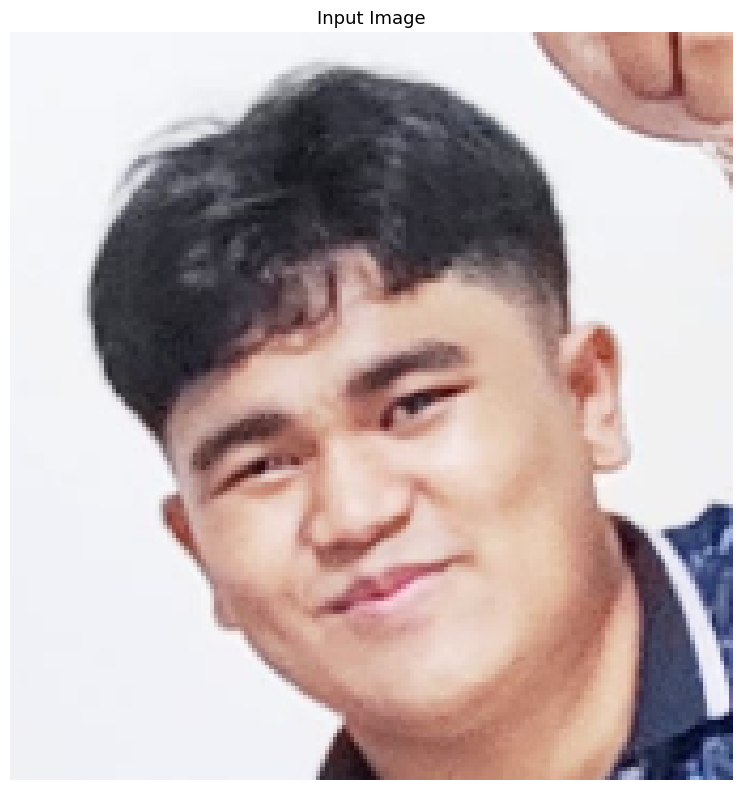

In [21]:
# ── Set your image path here ──────────────────────────────────────
IMAGE_FILE = "Screenshot 2026-03-28 152856.png"          # ← change to your photo path

# Auto-download sample if not found
if not os.path.exists(IMAGE_FILE):
    print("Downloading sample image...")
    r = requests.get("https://storage.googleapis.com/mediapipe-assets/business-person.png")
    with open(IMAGE_FILE, "wb") as f:
        f.write(r.content)

# Run MediaPipe
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)
detector    = vision.FaceLandmarker.create_from_options(options)
mp_image    = mp.Image.create_from_file(IMAGE_FILE)
result      = detector.detect(mp_image)

if not result.face_landmarks:
    print("❌ No face detected — use a clear, front-facing photo.")
else:
    lms = result.face_landmarks[0]
    print(f"✅ Face detected — {len(lms)} landmarks.")
    show_img(cv2.imread(IMAGE_FILE), "Input Image")

## Step 8 — Annotated face map (fixed Thai labels + zones)

C:\Users\TUF F16\AppData\Local\Temp\ipykernel_29604\2892820513.py:142: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


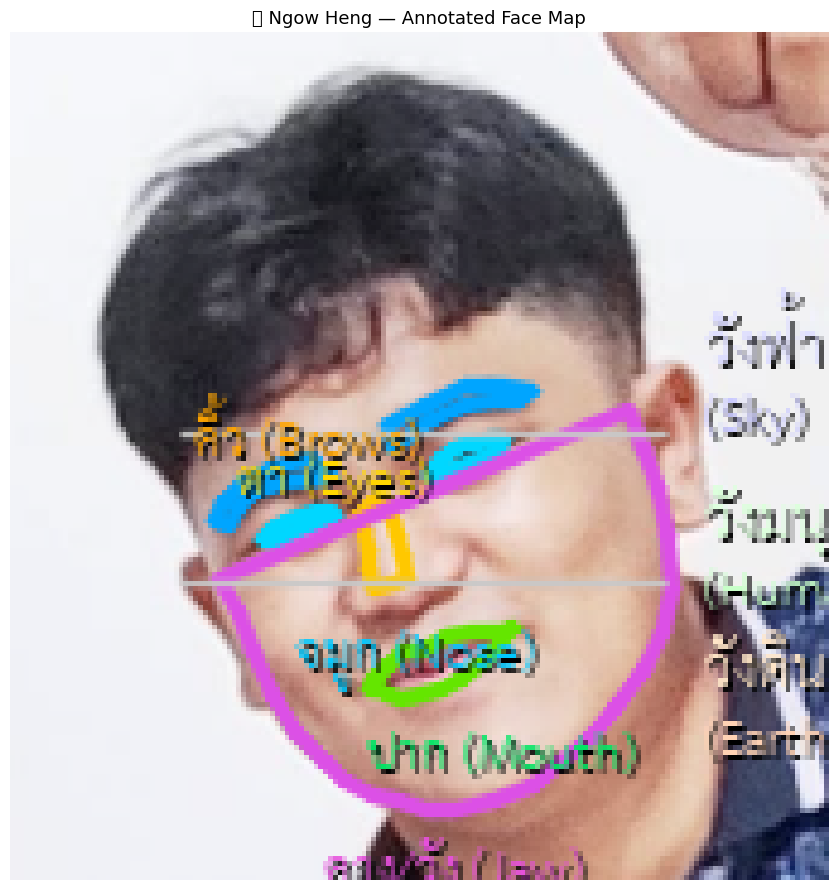

✅ Saved: ngow_heng_annotated.png


In [24]:
if result.face_landmarks:
    rgb       = mp_image.numpy_view()
    annotated = annotate_face(rgb, lms)
    show_img(annotated, "🔮 Ngow Heng — Annotated Face Map", figsize=(11, 9))
    cv2.imwrite("ngow_heng_annotated.png", annotated)
    print("✅ Saved: ngow_heng_annotated.png")

## Step 9 — Run analysis & print full report

In [25]:
if result.face_landmarks:
    e_r, e_s, e_m = analyze_eyes(lms)
    n_r, n_s, n_m = analyze_nose(lms)
    m_r, m_s, m_m = analyze_mouth(lms)
    j_r, j_s, j_m = analyze_jaw(lms)
    print_report(e_r, n_r, m_r, j_r, e_s, n_s, m_s, j_s, e_m, n_m, m_m, j_m)


══════════════════════════════════════════════════════════════
  🔮  NGOW HENG REPORT  (โหงวเฮ้ง)
══════════════════════════════════════════════════════════════
  Total: 15/24  [███████████████░░░░░░░░░]  62%
  ✨ โหงวเฮ้งดีพอใช้ — มีทั้งดีและควรระวัง

──────────────────────────────────────────────────────────────
  👁️  EYES (ตา) — Intelligence · Emotion · Trust   [Score: 4]
──────────────────────────────────────────────────────────────
  ❌  ตาเล็ก/สั้น
      → Small eyes — may lack wisdom
  ✅  ตาห่างพอดี
      → Well-spaced — honest & trustworthy
  ✅  ตาสมมาตร
      → Symmetric eyes — balanced life
  ✅  หว่างคิ้วกว้าง
      → Good brow-eye gap — patient, generous
  📐 Metrics: eye_aspect=0.218, eye_spacing=1.316, eye_symmetry=0.929, brow_gap=0.731

──────────────────────────────────────────────────────────────
  👃  NOSE (จมูก) — Wealth · Authority · Decisions   [Score: 2]
──────────────────────────────────────────────────────────────
  ❌  สันจมูกคด
      → Crooked bridge — unstable char